## Ex 1

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
m = 10
n = 6
A = np.random.rand(m, n)
U, s, VT = np.linalg.svd(A, full_matrices=True)
print(U.shape, s.shape, VT.shape)


(10, 10) (6,) (6, 6)


In [10]:
S = np.zeros((m, n))
S[:n, :n] = np.diag(s)
S.shape

(10, 6)

In [11]:
np.linalg.norm(A - U @ S @ VT) 

np.float64(3.4463363215392062e-15)

In [12]:
print('Singular values of A:', s)

Singular values of A: [4.31467947 1.2267851  1.00087238 0.74467578 0.53550168 0.24068294]


## Ex 2

In [14]:
def compress_matrix(U, S, VT, k):
    """Compress matrix using top k singular values and vectors."""
    U_k = U[:, :k]
    S_k = S[:k, :k]
    VT_k = VT[:k, :]
    A_k = U_k @ S_k @ VT_k
    return A_k

In [17]:
errors = []
for k in range(len(s)):
    A_k = compress_matrix(U, S, VT, k+1)
    error = np.linalg.norm(A - A_k)
    errors.append(error)
    print(f'Error with k={k+1}: {error}')

Error with k=1: 1.8455296119616214
Error with k=2: 1.3787595413189724
Error with k=3: 0.9482786203759561
Error with k=4: 0.5871033368513386
Error with k=5: 0.24068293571345076
Error with k=6: 3.4463363215392062e-15


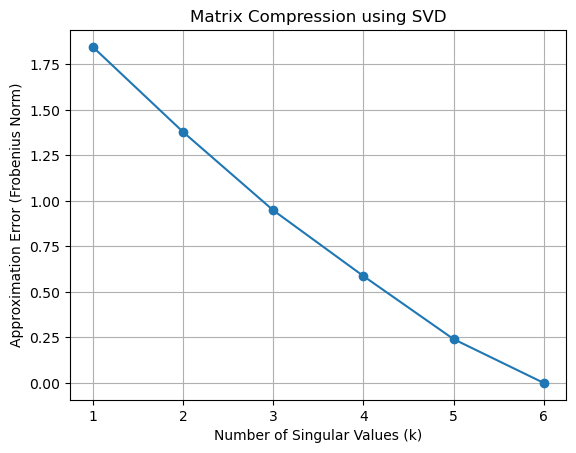

In [18]:
plt.plot(range(1, len(s)+1), errors, marker='o')
plt.xlabel('Number of Singular Values (k)')
plt.ylabel('Approximation Error (Frobenius Norm)')
plt.title('Matrix Compression using SVD')
plt.grid()
plt.show()


## Ex 2

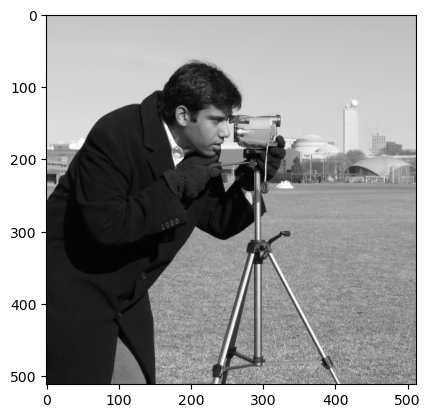

In [20]:
import skimage 

x = skimage.data.camera()
plt.imshow(x, cmap="gray")
plt.show()

In [22]:
U, s, VT = np.linalg.svd(x, full_matrices=False)
print("SVD: ",U.shape, " @ ", s.shape," @ ", VT.shape)

SVD:  (512, 512)  @  (512,)  @  (512, 512)


In [25]:
k_values = [5, 20, 50, 100, 200]

compression_results = pd.DataFrame(columns=['k', 'Compressed_Image', 'Error', 'compression factor'])

for k in k_values:
    x_k = compress_matrix(U, np.diag(s), VT, k)
    error = np.linalg.norm(x - x_k)
    m = U.shape[0]
    n = VT.shape[1]
    compression_factor = 1 - (k*(m + 1 + n) / (m*n))
    compression_results.loc[len(compression_results)] = [k, x_k, error, compression_factor]

display(compression_results.drop(columns=['Compressed_Image']))

,k,Error,compression factor
0,5,13086.868265,0.980450
1,20,7699.909142,0.921799
2,50,4836.068908,0.804497
3,100,2992.144382,0.608994
4,200,1342.358197,0.217987


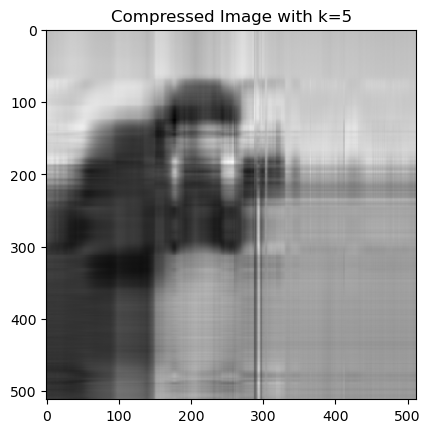

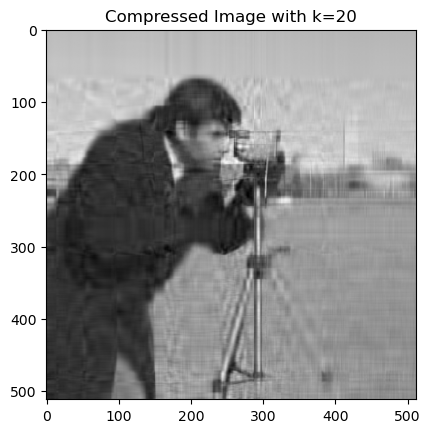

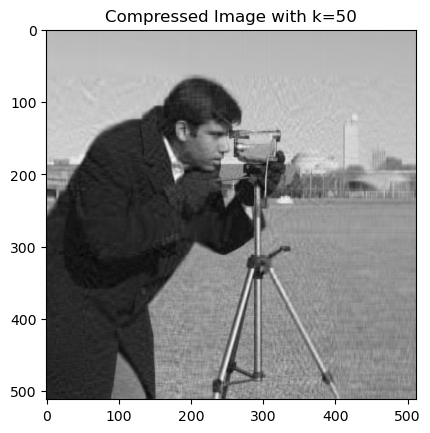

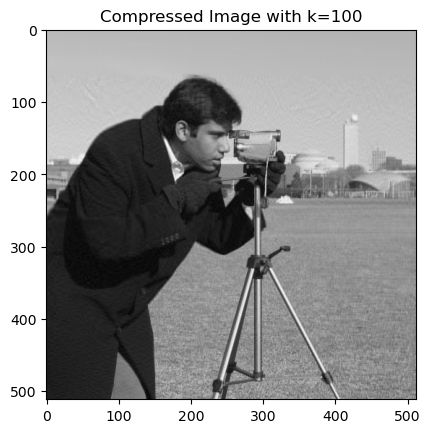

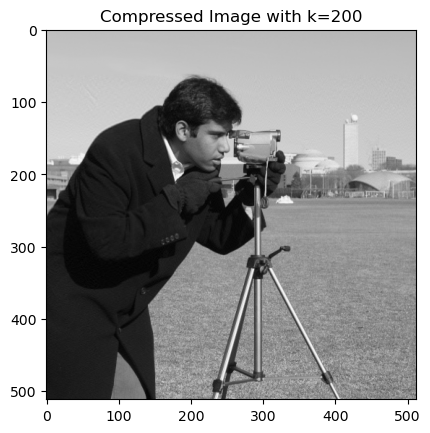

In [ ]:
for index, row in compression_results.iterrows():
    plt.imshow(row['Compressed_Image'], cmap='gray')
    plt.title(f'Compressed Image with k={row["k"]}')
    plt.show()

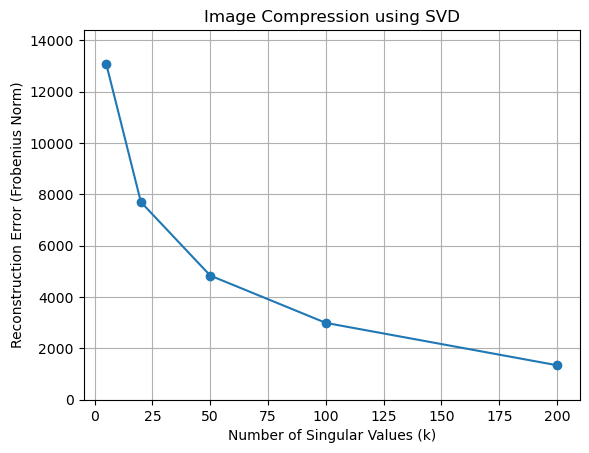

In [28]:
# plot reconstruction error vs k
plt.plot(compression_results['k'], compression_results['Error'], marker='o')
plt.xlabel('Number of Singular Values (k)')
plt.ylabel('Reconstruction Error (Frobenius Norm)')
plt.ylim(0, max(compression_results['Error']) * 1.1)
plt.title('Image Compression using SVD')
plt.grid()
plt.show()

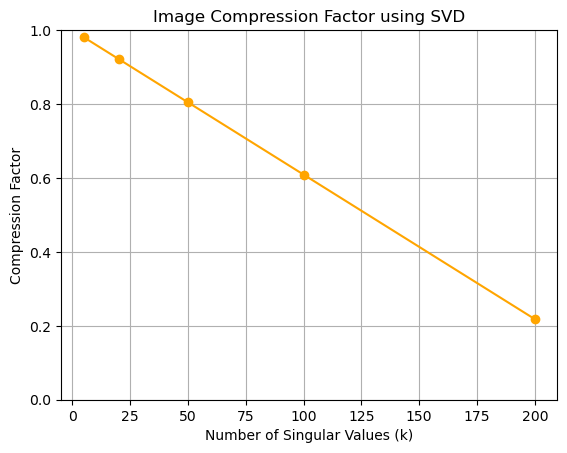

In [29]:
plt.plot(compression_results['k'], compression_results['compression factor'], marker='o', color='orange')
plt.xlabel('Number of Singular Values (k)')
plt.ylabel('Compression Factor')
plt.ylim(0, 1)
plt.title('Image Compression Factor using SVD')
plt.grid()
plt.show()

## Ex 5

In [31]:
import numpy as np
 

df = pd.read_csv('./MNIST.csv')
df.shape

(42000, 785)

In [32]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X = df.drop(columns=['label']).values
y = df['label'].values

print(f"Shape of the data: {X.shape}, Labels: {y.shape}")

Shape of the data: (42000, 784), Labels: (42000,)


In [37]:
filter_3or4 = (y==3) | (y==4)

X_filtered = X[filter_3or4]
Y_filtered = y[filter_3or4]

print(f"Final shape of X: {X_filtered.shape}. Final shape of Y: {Y_filtered.shape}")
print(f"Number of class 3 samples: {np.sum(Y_filtered==3)}")
print(f"Number of class 4 samples: {np.sum(Y_filtered==4)}")

Final shape of X: (8423, 784). Final shape of Y: (8423,)
Number of class 3 samples: 4351
Number of class 4 samples: 4072


In [41]:
N = X_filtered.shape[0]
random_indices = np.random.permutation(N)

N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]

X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]

print(f"Train set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Train set: 6738 samples, Test set: 1685 samples


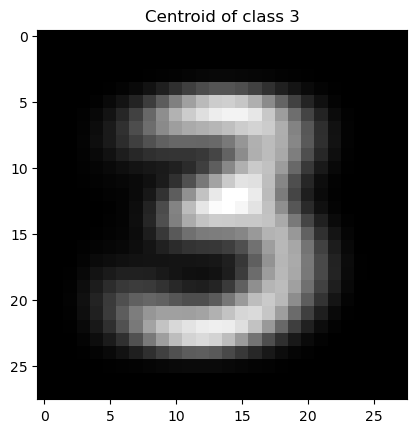

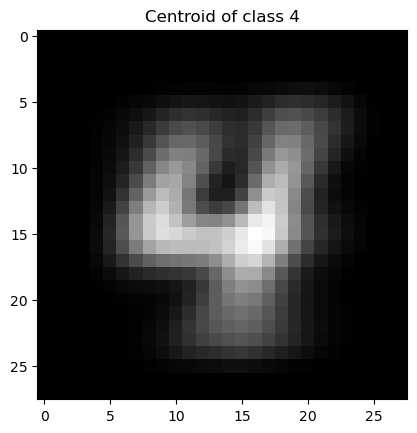

In [49]:
X_3 = X_filtered[Y_filtered==3]
X_4 = X_filtered[Y_filtered==4]

centroid_of_X_3 = np.mean(X_3, axis=0)
centroid_of_X_4 = np.mean(X_4, axis=0)

# Visualize centroids
img_3 = np.reshape(centroid_of_X_3, (28, 28))
plt.imshow(img_3, cmap='gray')
plt.title('Centroid of class 3')
plt.show()

img_4 = np.reshape(centroid_of_X_4, (28, 28))
plt.imshow(img_4, cmap='gray')
plt.title('Centroid of class 4')
plt.show()

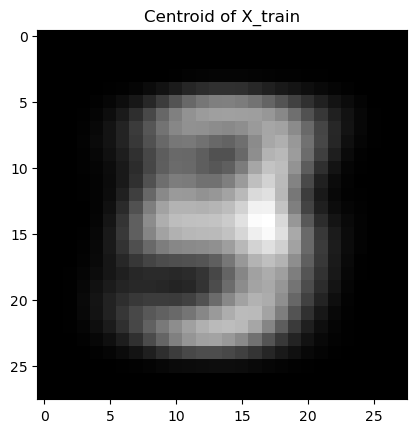

In [53]:
centroid_of_X_train = np.mean(X_train, axis=0)
centroid_of_X_test = np.mean(X_test, axis=0)

centroid_of_X_train_img = np.reshape(centroid_of_X_train, (28, 28))
plt.imshow(centroid_of_X_train_img, cmap='gray')
plt.title('Centroid of X_train')
plt.show()

In [56]:
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)
U_test, s_test, VT_test = np.linalg.svd(X_test_centered, full_matrices=False)

In [58]:
k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T

VTK_test = VT_test[:k]
P_test = VTK_test
Z_test = X_test_centered @ P_test.T

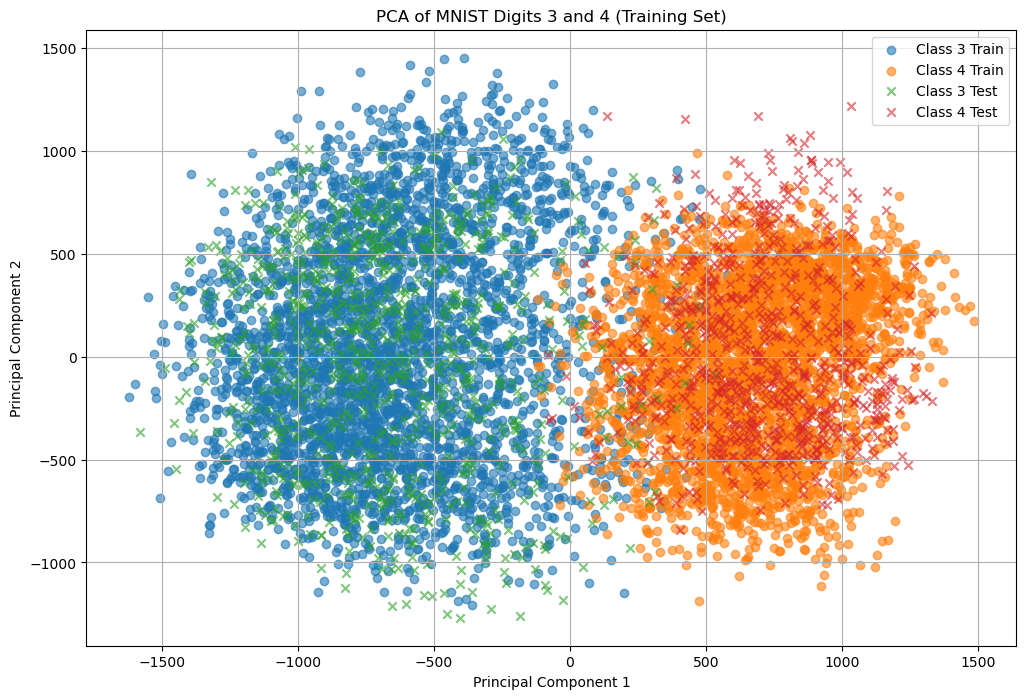

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==3, 0], Z_train[Y_train==3, 1], label='Class 3 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==4, 0], Z_train[Y_train==4, 1], label='Class 4 Train', alpha=0.6)
plt.scatter(Z_test[Y_test==3, 0], Z_test[Y_test==3, 1], label='Class 3 Test', alpha=0.6, marker='x')
plt.scatter(Z_test[Y_test==4, 0], Z_test[Y_test==4, 1], label='Class 4 Test', alpha=0.6, marker='x')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 3 and 4 (Training Set)')
plt.legend()
plt.grid()
plt.show()

In [66]:
filter_5or8 = (y==5) | (y==8)
X_filtered = X[filter_5or8]
Y_filtered = y[filter_5or8]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
centroid_of_X_test = np.mean(X_test, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)
U_test, s_test, VT_test = np.linalg.svd(X_test_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
VTK_test = VT_test[:k]
P_test = VTK_test
Z_test = X_test_centered @ P_test.T


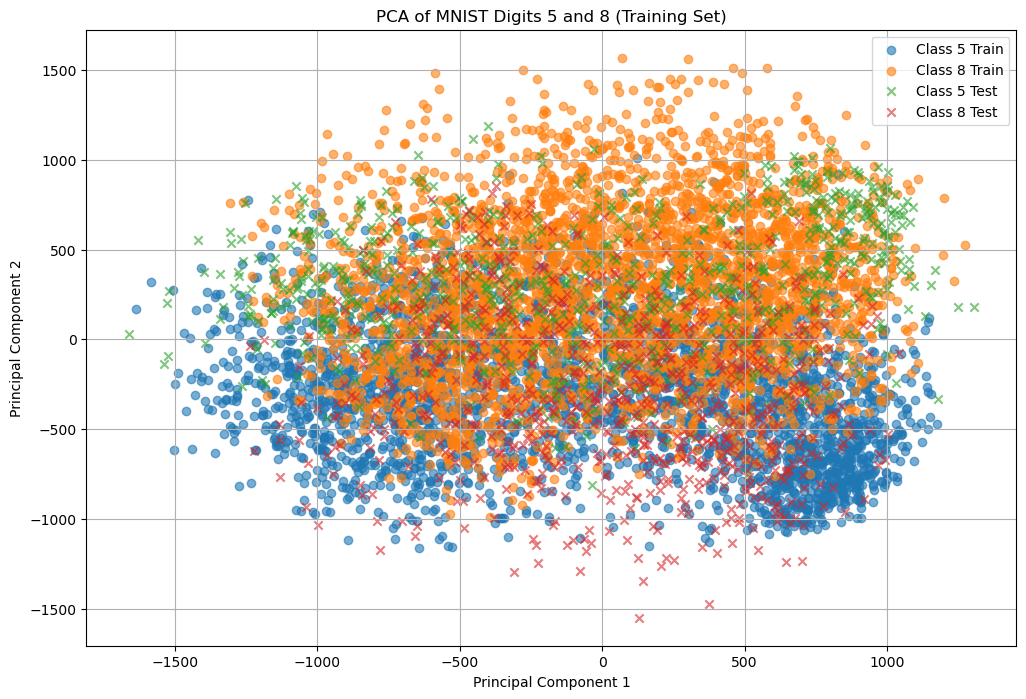

In [67]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==5, 0], Z_train[Y_train==5, 1], label='Class 5 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==8, 0], Z_train[Y_train==8, 1], label='Class 8 Train', alpha=0.6)
plt.scatter(Z_test[Y_test==5, 0], Z_test[Y_test==5, 1], label='Class 5 Test', alpha=0.6, marker='x')
plt.scatter(Z_test[Y_test==8, 0], Z_test[Y_test==8, 1], label='Class 8 Test', alpha=0.6, marker='x')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 5 and 8 (Training Set)')
plt.legend()
plt.grid()
plt.show()

In [63]:
filter_1or7 = (y==1) | (y==7)
X_filtered = X[filter_1or7]
Y_filtered = y[filter_1or7]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
centroid_of_X_test = np.mean(X_test, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)
U_test, s_test, VT_test = np.linalg.svd(X_test_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
VTK_test = VT_test[:k]
P_test = VTK_test
Z_test = X_test_centered @ P_test.T


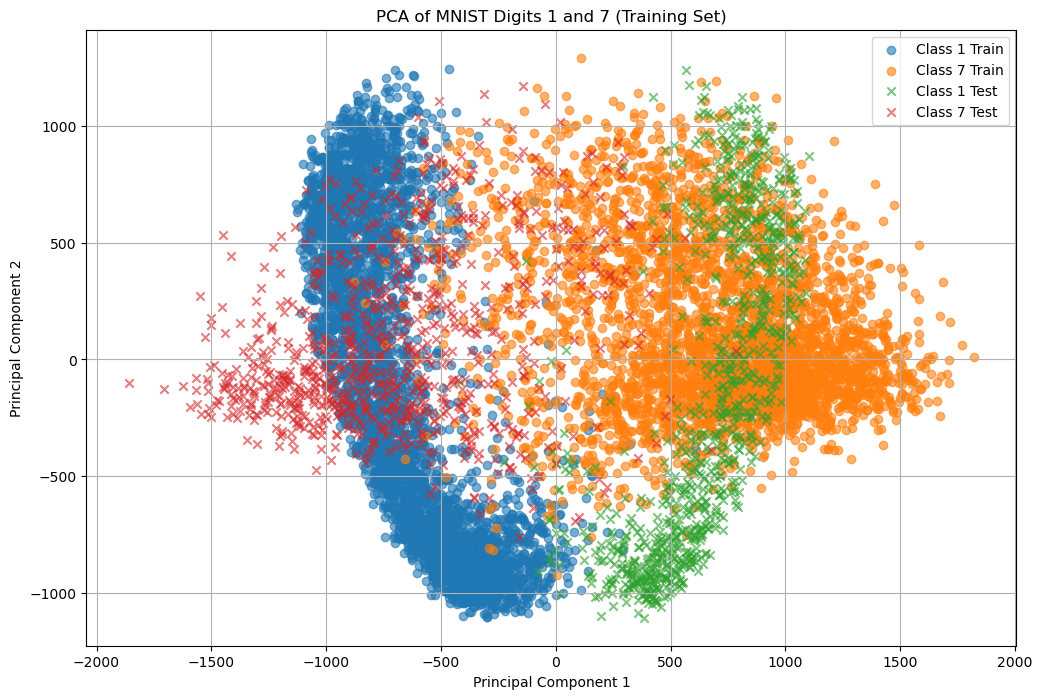

In [64]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==1, 0], Z_train[Y_train==1, 1], label='Class 1 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==7, 0], Z_train[Y_train==7, 1], label='Class 7 Train', alpha=0.6)
plt.scatter(Z_test[Y_test==1, 0], Z_test[Y_test==1, 1], label='Class 1 Test', alpha=0.6, marker='x')
plt.scatter(Z_test[Y_test==7, 0], Z_test[Y_test==7, 1], label='Class 7 Test', alpha=0.6, marker='x')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 1 and 7 (Training Set)')
plt.legend()
plt.grid()
plt.show()

In [68]:
filter_3or4 = (y==3) | (y==4)
X_filtered = X[filter_3or4]
Y_filtered = y[filter_3or4]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
centroid_of_X_test = np.mean(X_test, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)
U_test, s_test, VT_test = np.linalg.svd(X_test_centered, full_matrices=False)

k = 3
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
VTK_test = VT_test[:k]
P_test = VTK_test
Z_test = X_test_centered @ P_test.T


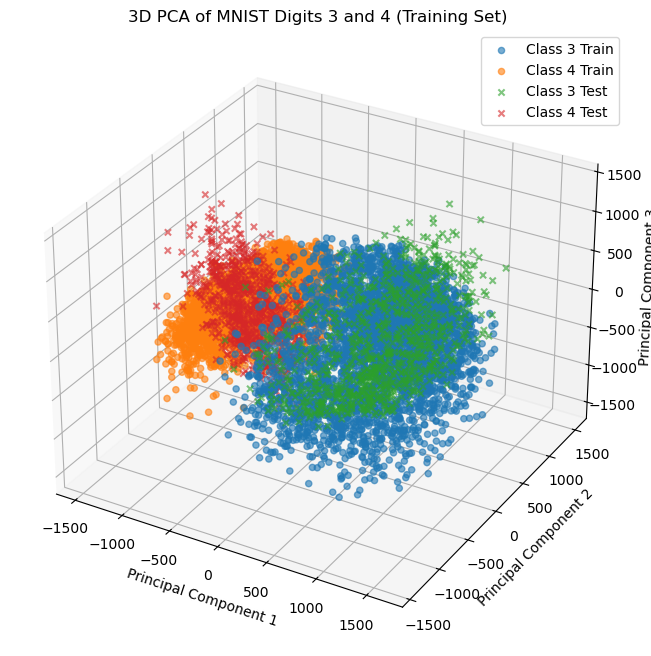

In [71]:
#3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Z_train[Y_train==3, 0], Z_train[Y_train==3, 1], Z_train[Y_train==3, 2], label='Class 3 Train', alpha=0.6)
ax.scatter(Z_train[Y_train==4, 0], Z_train[Y_train==4, 1], Z_train[Y_train==4, 2], label='Class 4 Train', alpha=0.6)
ax.scatter(Z_test[Y_test==3, 0], Z_test[Y_test==3, 1], Z_test[Y_test==3, 2], label='Class 3 Test', alpha=0.6, marker='x')
ax.scatter(Z_test[Y_test==4, 0], Z_test[Y_test==4, 1], Z_test[Y_test==4, 2], label='Class 4 Test', alpha=0.6, marker='x')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.title('3D PCA of MNIST Digits 3 and 4 (Training Set)')
plt.legend()
plt.show()

## Ex6

In [72]:
filter_3or4 = (y==3) | (y==4)
X_filtered = X[filter_3or4]
Y_filtered = y[filter_3or4]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
centroid_of_X_test = np.mean(X_test, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)
U_test, s_test, VT_test = np.linalg.svd(X_test_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
VTK_test = VT_test[:k]
P_test = VTK_test
Z_test = X_test_centered @ P_test.T
